# Air Quality Philippines
## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Donec non ligula ut dui pellentesque varius ut sit amet sapien. Fusce augue sapien, maximus ut sodales sagittis, suscipit ut lorem. Integer lacus dolor, ultrices et erat at, cursus elementum diam. Fusce sem purus, aliquet at iaculis non, blandit sed ex.

## Table of Contents
- [About the Dataset](#aboutdataset)
- [Research Questions](#researchquestions)
- [Data Wrangling](#datawrangling)
- [Exploratory Data Analysis](#eda)
- [Summary of Insights](#summary)

<hr>

### About the Dataset
<a id="aboutdataset"></a>

## Research Questions
1. How do pollutant concentrations (specifically $PM_{2.5}$ and $NO_{2}$) vary across the distinct Philippine seasons, and is there a significant spike during the dry season (Amihan) compared to the wet season (Habagat)?
2. Is there a statistically significant "weekend effect" where $NO_{2}$ and $CO$ levels drop in highly urbanized cities (like Navotas or Zamboanga) compared to weekdays?
3. To what degree do high surface temperatures and solar radiation correlate with the formation of ground-level Ozone ($O_{3}$) across the 12 cities?
4. How did the 2020–2022 period (COVID-19 lockdowns and recovery) deviate from the 15-year historical baseline (2003–2018) for $PM_{2.5}$ levels?
5. Which of the 12 cities in the CCHAIN dataset consistently exceeds the WHO's recommended annual limits for $PM_{2.5}$, and does this correlate with high population density?

<hr>

## Data Wrangling
<a id="datawrangling"></a>
We will first prepare the environment by loading the necessary libraries and importing the datasets. Next, we will assess the dataset to see if it needs cleaning.

### Preparing the Environment

In [36]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Importing necessary datasets
air_quality = pd.read_csv("/kaggle/input/project-cchain/climate_air_quality.csv")

### Assessing the dataset

In [3]:
air_quality.info(show_counts=True)    # the argument is necessary since the dataset is too large

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6421095 entries, 0 to 6421094
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   uuid        6421095 non-null  object 
 1   adm4_pcode  6421095 non-null  object 
 2   date        6421095 non-null  object 
 3   freq        6421095 non-null  object 
 4   no2         6420216 non-null  float64
 5   co          6421095 non-null  float64
 6   so2         6421095 non-null  float64
 7   o3          6421095 non-null  float64
 8   pm10        6420216 non-null  float64
 9   pm25        6420216 non-null  float64
dtypes: float64(6), object(4)
memory usage: 489.9+ MB


In [4]:
# Fix the data type of the date column
air_quality['date'] = pd.to_datetime(air_quality['date'])

In [5]:
air_quality.describe()

,date,no2,co,so2,o3,pm10,pm25
count,6421095,6.420216e+06,6.421095e+06,6.421095e+06,6.421095e+06,6.420216e+06,6.420216e+06
mean,2012-12-31 00:00:00.000000256,1.463997e+00,7.871316e-02,6.225348e-01,3.162343e+01,2.574457e+01,1.774573e+01
min,2003-01-01 00:00:00,4.000000e-02,4.580000e-02,2.000000e-02,2.184000e+01,2.100000e+00,1.450000e+00
25%,2008-01-01 00:00:00,3.900000e-01,6.270000e-02,1.600000e-01,2.733000e+01,1.564000e+01,1.054000e+01
50%,2012-12-31 00:00:00,1.210000e+00,7.100000e-02,3.300000e-01,3.024000e+01,2.072000e+01,1.415000e+01
75%,2017-12-31 00:00:00,1.760000e+00,8.400000e-02,6.300000e-01,3.508000e+01,2.879000e+01,1.993000e+01
max,2022-12-31 00:00:00,1.467000e+01,2.653700e+00,1.174000e+01,5.357000e+01,1.846100e+02,1.316000e+02
std,NaN,1.522753e+00,3.482520e-02,9.622988e-01,5.031181e+00,1.722190e+01,1.220795e+01


### Investigating Null Values
There seem to be null values in columns no2, pm10, and pm25. Let's investigate this.

In [6]:
# To see if the null values are all in the same rows
null_no2 = air_quality[air_quality['no2'].isna()][['uuid']]
null_pm10 = air_quality[air_quality['pm10'].isna()][['uuid']]
null_pm25 = air_quality[air_quality['pm25'].isna()][['uuid']]
print((null_no2==null_pm10).sum())
print((null_no2==null_pm25).sum())

uuid    879
dtype: int64
uuid    879
dtype: int64


In [7]:
# To see which cities were affected by the null values
null_rows = air_quality[air_quality.isnull().any(axis=1)][['adm4_pcode', 'date']]
null_rows['adm4_pcode'] = null_rows['adm4_pcode'].str[:8]
null_rows['adm4_pcode'].unique()

array(['PH015518', 'PH034919', 'PH050506', 'PH063022', 'PH072230',
       'PH083747', 'PH097332', 'PH104305', 'PH112402', 'PH137401',
       'PH137503', 'PH137603'], dtype=object)

In [8]:
# To see which dates were affected by the null values
null_rows['year'] = null_rows['date'].dt.year
null_rows['month'] = null_rows['date'].dt.month
null_rows['day'] = null_rows['date'].dt.day
print("year: ",null_rows['year'].unique())
print("month: ",null_rows['month'].unique())
print("day: ",null_rows['day'].unique())

year:  [2003]
month:  [1]
day:  [1]


The investigation showed that all 12 barangays were affected by the null values, but only on one day (Jan. 1, 2003). This is probably due to a system failure during that day. We will take this in mind while doing our analysis later on.

### Aggregating Records
Since our analysis will be on a national level, city-wide values will only be needed. And since the dataset is provided at the barangay level, we will aggregate it to simplify the dataset.

We use the first 8 characters of the adm4_pcode to get the adm3_pcode or the city code. We then drop the unwanted columns: uuid and freq.

In [9]:
air_quality['adm4_pcode'] = air_quality['adm4_pcode'].str[:8]        # Slice the code to get the city code
air_quality.rename(columns={'adm4_pcode': 'adm3_pcode'}, inplace=True)
air_quality.drop(['uuid', 'freq'], axis=1, inplace=True)             # Drop unwanted columns
air_quality.head()

,adm3_pcode,date,no2,co,so2,o3,pm10,pm25
0,PH015518,2003-01-02,3.66,0.1034,0.31,38.39,23.63,16.21
1,PH015518,2003-01-03,4.35,0.1010,0.70,38.37,34.43,23.82
2,PH015518,2003-01-04,3.82,0.1016,0.34,37.72,27.76,19.16
3,PH015518,2003-01-05,3.07,0.1053,0.24,38.44,31.26,20.64
4,PH015518,2003-01-06,3.02,0.0953,0.22,39.89,24.70,16.68


We aggregate the data by using the city code and the date as indices and get their means.

In [10]:
monthly_city_data = air_quality.groupby(['adm3_pcode', pd.Grouper(key='date', freq='ME')]).mean()
monthly_city_data = monthly_city_data.reset_index()

In [11]:
monthly_city_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   adm3_pcode  2880 non-null   object        
 1   date        2880 non-null   datetime64[ns]
 2   no2         2880 non-null   float64       
 3   co          2880 non-null   float64       
 4   so2         2880 non-null   float64       
 5   o3          2880 non-null   float64       
 6   pm10        2880 non-null   float64       
 7   pm25        2880 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 180.1+ KB


This new dataframe makes sense since there are 12 cities, each with monthly data from January 2003 to December 2022.

### Naming Cities
From the city codes, we create another column for the names of the cities for future visualizations. The data of the names are stored in another dataset.

In [12]:
location = pd.read_csv("/kaggle/input/project-cchain/location.csv")
location.head()

,Unnamed: 0,adm1_en,adm1_pcode,adm2_en,adm2_pcode,adm3_en,adm3_pcode,adm4_en,adm4_pcode,brgy_total_area
0,0,Region I,PH010000000,Pangasinan,PH015500000,Dagupan City,PH015518000,Lomboy,PH015518016,1.0216
1,1,Region I,PH010000000,Pangasinan,PH015500000,Dagupan City,PH015518000,Tapuac,PH015518031,1.0440
2,2,Region I,PH010000000,Pangasinan,PH015500000,Dagupan City,PH015518000,Pantal,PH015518022,3.2625
3,3,Region I,PH010000000,Pangasinan,PH015500000,Dagupan City,PH015518000,Barangay I (T. Bugallon),PH015518024,0.1814
4,4,Region III,PH030000000,Nueva Ecija,PH034900000,Palayan City,PH034919000,Imelda Valley,PH034919017,6.3369


In [13]:
location.drop(['Unnamed: 0', 'adm1_en', 'adm1_pcode', 'adm2_en','adm2_pcode', 
               'adm4_en', 'adm4_pcode', 'brgy_total_area'], axis=1, inplace=True)  # Drop unwanted columns

location['adm3_pcode'] = location['adm3_pcode'].str[:8]   # Slice the code
location.drop_duplicates(keep='last', inplace=True)       # To keep only the unique cities (12)

location.head()

,adm3_en,adm3_pcode
588,City of Muntinlupa,PH137603
737,Dagupan City,PH015518
739,Palayan City,PH034919
749,Legazpi City,PH050506
779,Iloilo City,PH063022


In [15]:
monthly_city_data = pd.merge(monthly_city_data, location, on='adm3_pcode', how='left')

In [16]:
monthly_city_data.head()

,adm3_pcode,date,no2,co,so2,o3,pm10,pm25,adm3_en
0,PH015518,2003-01-31,4.127667,0.108147,0.599927,38.063985,33.309667,23.125667,Dagupan City
1,PH015518,2003-02-28,4.426786,0.107504,0.557730,37.909435,30.451071,21.404286,Dagupan City
2,PH015518,2003-03-31,4.230000,0.102469,0.743351,40.545120,34.934839,24.636774,Dagupan City
3,PH015518,2003-04-30,3.515667,0.088717,0.949796,39.681398,33.005333,23.300667,Dagupan City
4,PH015518,2003-05-31,3.194839,0.085250,1.310957,36.222529,30.127097,21.050968,Dagupan City


Now our monthly data is complete and clean for further analysis. 

## Exploratory Data Analysis

### Q1: How do pollutant concentrations (specifically $PM_{2.5}$ and $NO_{2}$) vary across the distinct Philippine seasons, and is there a significant spike during the dry season (Amihan) compared to the wet season (Habagat)?

For this, we have to consider that there are 4 climate types in the Philippines. 
- Type I: Maximum rain period from June to September
- Type II: Maximum rain period from December to February
- Type III: Short dry season from December to February
- Type IV: rainfall is evenly distributed throughout the year.

For this, we pick sample cities for each climate types:
- Type I: Dagupan City
- Type II: Legazpi City
- Type III: Mandaue City
- Type IV: Davao City

In [17]:
# Get sub dataframes for each sample city
dagupan_city = monthly_city_data.query('adm3_pcode == "PH015518"')[['date', 'pm25', 'no2']]
legazpi_city = monthly_city_data.query('adm3_pcode == "PH050506"')[['date', 'pm25', 'no2']]
mandaue_city = monthly_city_data.query('adm3_pcode == "PH07223"')[['date', 'pm25', 'no2']]
davao_city = monthly_city_data.query('adm3_pcode == "PH112402"')[['date', 'pm25', 'no2']]

# Add column for month names
dagupan_city['month'] = dagupan_city['date'].dt.month_name() 
legazpi_city['month'] = legazpi_city['date'].dt.month_name() 
mandaue_city['month'] = mandaue_city['date'].dt.month_name() 
davao_city['month'] = davao_city['date'].dt.month_name() 

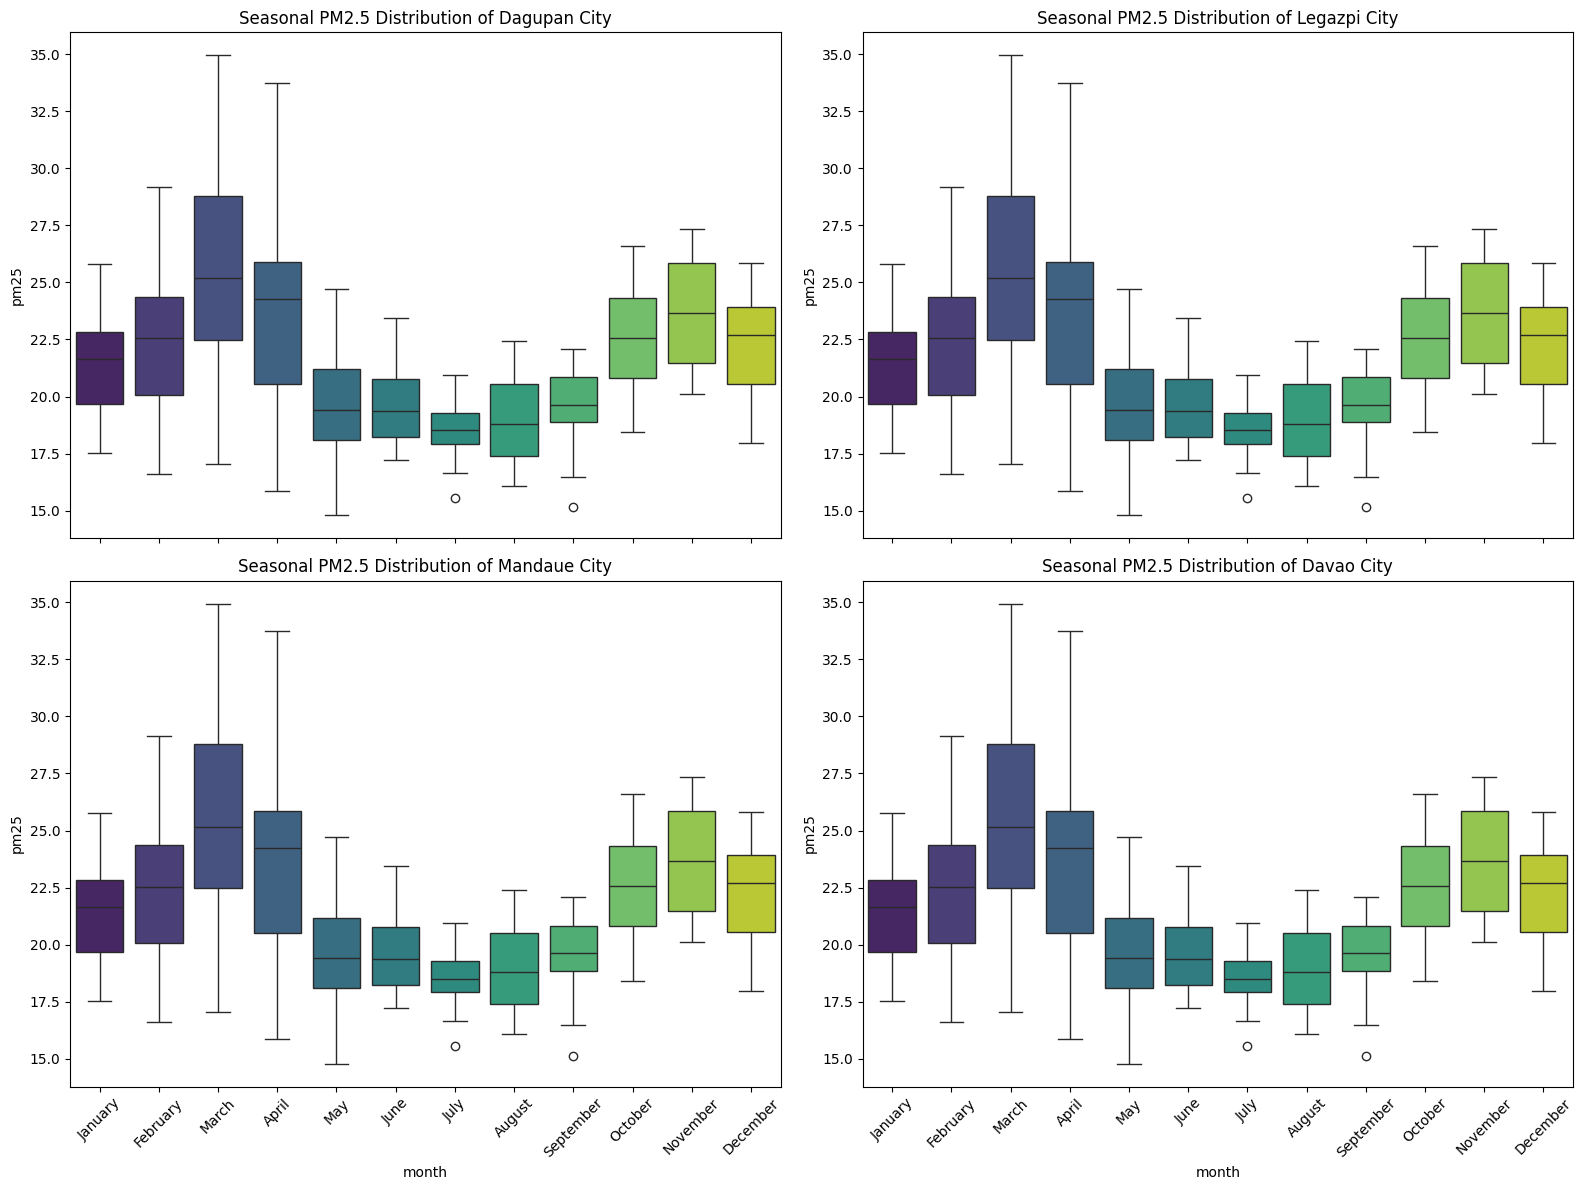

In [18]:
cities = [dagupan_city, legazpi_city, mandaue_city, davao_city]
city_names = ['Dagupan City', 'Legazpi City', 'Mandaue City', 'Davao City']

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

# Loop through the axes and cities to fill the grid
for i, cities in enumerate(cities):
    row = i // 2
    col = i % 2
    
    sns.boxplot(
        ax=axes[row, col],
        x='month', 
        y='pm25', 
        data=dagupan_city, 
        hue='month',
        legend=False,
        palette="viridis",
        order=month_order
    )
    
    axes[row, col].set_title(f'Seasonal PM2.5 Distribution of {city_names[i]}')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

NameError: name 'city_df' is not defined

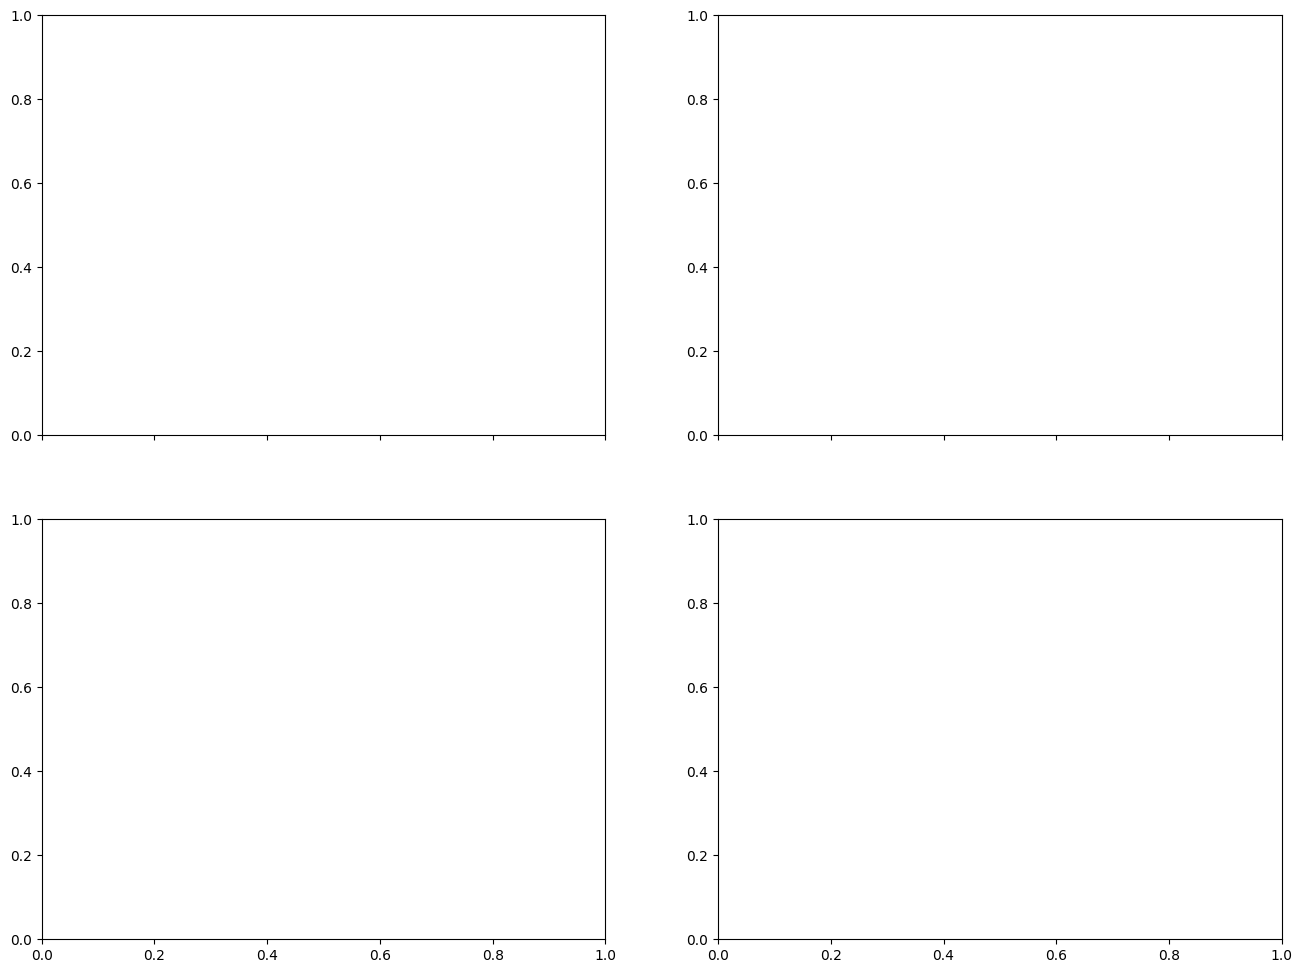

In [19]:
cities = [dagupan_city, legazpi_city, mandaue_city, davao_city]
city_names = ['Dagupan City', 'Legazpi City', 'Mandaue City', 'Davao City']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

# Loop through the axes and cities to fill the grid
for i, cities in enumerate(cities):
    row = i // 2
    col = i % 2

    df_clean = city_df.copy()
    result = seasonal_decompose(cities['pm25'], model='additive', period=12)
    
    # Plot the decomposition
    axes[row, col].plot(result.seasonal, color='teal', linewidth=2)
    axes[row, col].set_title(f'Seasonal PM2.5 Distribution of {city_names[i]}')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Interpretation
Interpretation here.

### Q2: Is there a statistically significant "weekend effect" where $NO_{2}$ and $CO$ levels drop in highly urbanized cities (like Navotas or Zamboanga) compared to weekdays?

For this, we need random samples of $NO_{2}$ and $CO$ during weekends and weekdays. To factor out the difference in climate types between cities, let us only pick one city for this analysis, say Zamboanga City.

We then perform hypothesis testing using One-Way ANOVA.

In [25]:
zamboanga_city = air_quality.query('adm3_pcode == "PH097332"')[['date','no2','co']].reset_index(drop=True)
zamboanga_city.head()

,date,no2,co
0,2003-01-02,0.36,0.0681
1,2003-01-03,0.30,0.0719
2,2003-01-04,0.23,0.0788
3,2003-01-05,0.25,0.0739
4,2003-01-06,0.25,0.0775


In [27]:
zamboanga_city['day'] = zamboanga_city['date'].dt.day_name()
zamboanga_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737805 entries, 0 to 737804
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    737805 non-null  datetime64[ns]
 1   no2     737704 non-null  float64       
 2   co      737805 non-null  float64       
 3   day     737805 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 22.5+ MB


In [28]:
weekends = ['Sunday', 'Saturday']
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends_sample = zamboanga_city.query('day in @weekends').sample(n=100)
weekdays_sample = zamboanga_city.query('day in @weekdays').sample(n=100)

In [34]:
weekends_sample.groupby('day')['no2'].sum()

day
Saturday     6.32
Sunday      10.10
Name: no2, dtype: float64

### Check for ANOVA assumptions

In [40]:
# Levene's Test for Homogeneity of Variance
levene_stat, levene_p_value_co = stats.levene(weekends_sample['co'], weekdays_sample['co'])
levene_stat, levene_p_value_no2 = stats.levene(weekends_sample['no2'], weekdays_sample['no2'])

# Shapiro-Wilk test for Normality
statistic, shapiro_p_value_co = stats.shapiro(np.concatenate([weekends_sample['co'], weekdays_sample['co']]))
statistic, shapiro_p_value_no2 = stats.shapiro(np.concatenate([weekends_sample['no2'], weekdays_sample['no2']]))

if levene_p_value_co > 0.05:
    print("CO equal variances:", levene_p_value_co)
else:
    print("CO Violated!", levene_p_value_co)
if levene_p_value_no2 > 0.05:
    print("NO2 equal variances:", levene_p_value_no2)
else:
    print("NO2 homoscedasticity violated!", levene_p_value_no2)

if shapiro_p_value_co > 0.05:
    print("CO normality:", shapiro_p_value_co)
else:
    print("CO normality violated!", shapiro_p_value_co)
if shapiro_p_value_no2 > 0.05:
    print("NO2 normality:", shapiro_p_value_no2)
else:
    print("NO2 normality violated!", shapiro_p_value_no2)

CO equal variances: 0.13289957093743207
NO2 homoscedasticity violated! 0.04463582134349309
CO normality violated! 1.2769459605023082e-22
NO2 normality violated! 1.7879711941306943e-07


## References
* Basconcillo, Joseph & Lucero, Anthony & Solis, Analiza & Jr, Robert & Bautista, Eulito & Koizumi, Tatsuji & Kanamaru, Hideki. (2016). Statistically Downscaled Projected Changes in Seasonal Mean Temperature and Rainfall in Cagayan Valley, Philippines. Journal of the Meteorological Society of Japan. Ser. II. 94A. 151-164. 10.2151/jmsj.2015-058.
* 